# House Price Analytics & Prediction
**Author:** Amir Muaviya Khan  |  **Program:** AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026 (BharatCares)

**Dataset:** [House Prices - Advanced Regression Techniques (Kaggle)](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques) - `train.csv` (1,460 houses, 81 columns)

## Problem Statement
A real-estate business wants to understand **what drives house prices**, track the key numbers (KPIs) that describe the market, and **predict the sale price** of a house from its features, so that it can price properties correctly and decide where to invest.

## Project Flow
Data -> Cleaning -> KPIs -> Exploratory Data Analysis (EDA) -> Prediction Model -> Risks, Opportunities & Recommended Actions

> **How to run:** put `train.csv` in the same folder as this notebook (in Google Colab, upload it using the folder icon on the left), then choose *Runtime -> Run all* (Colab) or *Run All* (Jupyter).

## 1. Import Libraries

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
os.makedirs("charts", exist_ok=True)
RESULTS = {}   # numbers collected here are reused in the project report
print("Libraries loaded")

Libraries loaded


## 2. Load the Data

In [2]:
df = pd.read_csv("train.csv")
print("Rows, Columns:", df.shape)
df.head()

Rows, Columns: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Quick look at the structure
print(df.dtypes.value_counts())
print()
print("Duplicate rows:", df.duplicated().sum())
df[["SalePrice","GrLivArea","LotArea","OverallQual","YearBuilt"]].describe().round(1)

str        43
int64      35
float64     3
Name: count, dtype: int64

Duplicate rows: 0


,SalePrice,GrLivArea,LotArea,OverallQual,YearBuilt
count,1460.0,1460.0,1460.0,1460.0,1460.0
mean,180921.2,1515.5,10516.8,6.1,1971.3
std,79442.5,525.5,9981.3,1.4,30.2
min,34900.0,334.0,1300.0,1.0,1872.0
25%,129975.0,1129.5,7553.5,5.0,1954.0
50%,163000.0,1464.0,9478.5,6.0,1973.0
75%,214000.0,1776.8,11601.5,7.0,2000.0
max,755000.0,5642.0,215245.0,10.0,2010.0


## 3. Data Cleaning
Many "missing" values in this dataset are not errors: for columns like `PoolQC`, `Alley` or `GarageType`, a blank means the house **does not have** that feature (the dataset description says so). These are filled with `"None"`. True gaps are filled with sensible statistics.

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
RESULTS["cols_with_missing_before"] = int(len(missing))
RESULTS["missing_cells_before"] = int(missing.sum())
print("Columns with missing values:", len(missing))
missing.to_frame("missing_count").assign(percent=lambda d: (d.missing_count/len(df)*100).round(1))

Columns with missing values: 19


,missing_count,percent
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


In [5]:
clean = df.copy()

# 1) Blank = feature not present -> "None"
none_cols = ["Alley","BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2",
             "FireplaceQu","GarageType","GarageFinish","GarageQual","GarageCond",
             "PoolQC","Fence","MiscFeature","MasVnrType"]
for c in none_cols:
    clean[c] = clean[c].fillna("None")

# 2) Numeric gaps
clean["LotFrontage"] = clean.groupby("Neighborhood")["LotFrontage"].transform(lambda s: s.fillna(s.median()))
clean["LotFrontage"] = clean["LotFrontage"].fillna(clean["LotFrontage"].median())
clean["MasVnrArea"]  = clean["MasVnrArea"].fillna(0)
clean["GarageYrBlt"] = clean["GarageYrBlt"].fillna(clean["YearBuilt"])   # no garage -> use year built

# 3) One missing categorical value -> most common value
clean["Electrical"] = clean["Electrical"].fillna(clean["Electrical"].mode()[0])

# 4) Remove duplicates (none expected) and the ID column (not useful for analysis)
clean = clean.drop_duplicates().drop(columns=["Id"])

RESULTS["missing_cells_after"] = int(clean.isnull().sum().sum())
print("Missing values after cleaning:", RESULTS["missing_cells_after"])
print("Final shape:", clean.shape)

Missing values after cleaning: 0
Final shape: (1460, 80)


### Feature engineering
New columns that describe a house in a way buyers think about it.

In [6]:
clean["TotalSF"]    = clean["TotalBsmtSF"] + clean["1stFlrSF"] + clean["2ndFlrSF"]
clean["HouseAge"]   = clean["YrSold"] - clean["YearBuilt"]
clean["TotalBath"]  = clean["FullBath"] + 0.5*clean["HalfBath"] + clean["BsmtFullBath"] + 0.5*clean["BsmtHalfBath"]
clean["PricePerSqFt"] = clean["SalePrice"] / clean["GrLivArea"]
clean[["TotalSF","HouseAge","TotalBath","PricePerSqFt"]].describe().round(1)

,TotalSF,HouseAge,TotalBath,PricePerSqFt
count,1460.0,1460.0,1460.0,1460.0
mean,2567.0,36.5,2.2,120.6
std,821.7,30.3,0.8,31.4
min,334.0,0.0,1.0,28.4
25%,2009.5,8.0,2.0,99.8
50%,2474.0,35.0,2.0,120.1
75%,3004.0,54.0,2.5,138.7
max,11752.0,136.0,6.0,276.3


## 4. Key Performance Indicators (KPIs)
Four numbers that summarise the market at a glance.

In [7]:
avg_price    = clean["SalePrice"].mean()
median_price = clean["SalePrice"].median()
avg_ppsf     = clean["PricePerSqFt"].mean()
nb_avg       = clean.groupby("Neighborhood")["SalePrice"].agg(["mean","count"])
top_nb       = nb_avg[nb_avg["count"] >= 10]["mean"].idxmax()
top_nb_price = nb_avg.loc[top_nb, "mean"]

RESULTS.update(avg_price=avg_price, median_price=median_price, avg_ppsf=avg_ppsf,
               top_nb=top_nb, top_nb_price=top_nb_price, n_houses=int(len(clean)),
               min_price=float(clean.SalePrice.min()), max_price=float(clean.SalePrice.max()))

print(f"KPI 1 - Average sale price        : ${avg_price:,.0f}")
print(f"KPI 2 - Median sale price         : ${median_price:,.0f}")
print(f"KPI 3 - Average price per sq. ft. : ${avg_ppsf:,.1f}")
print(f"KPI 4 - Priciest neighbourhood    : {top_nb} (avg ${top_nb_price:,.0f}, neighbourhoods with 10+ sales)")

KPI 1 - Average sale price        : $180,921
KPI 2 - Median sale price         : $163,000
KPI 3 - Average price per sq. ft. : $120.6
KPI 4 - Priciest neighbourhood    : NoRidge (avg $335,295, neighbourhoods with 10+ sales)


## 5. Exploratory Data Analysis (EDA)

### Chart 1 - How are prices distributed? (Trend / shape of the market)

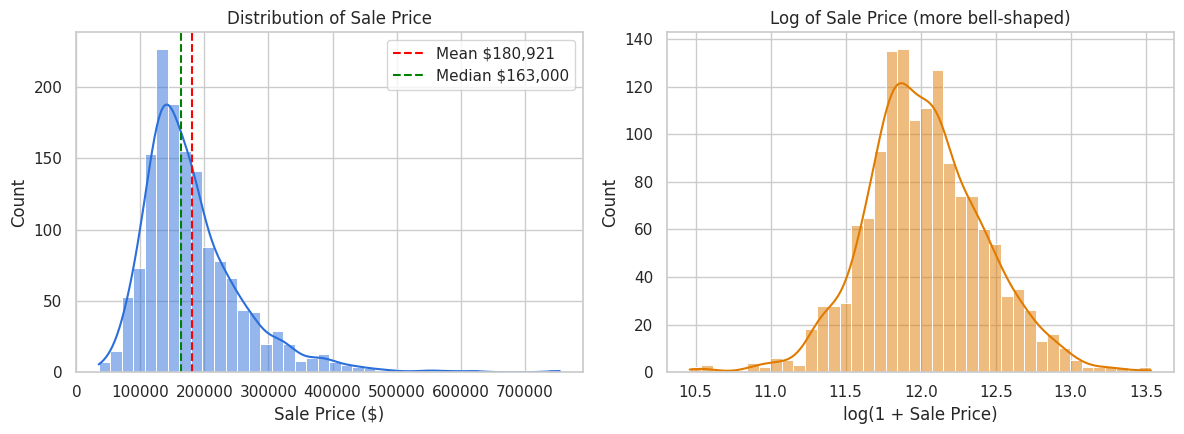

Skewness = 1.88: a few expensive houses pull the mean above the median.


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(clean["SalePrice"], bins=40, kde=True, color="#2a6fdb", ax=ax[0])
ax[0].axvline(avg_price, color="red", ls="--", label=f"Mean ${avg_price:,.0f}")
ax[0].axvline(median_price, color="green", ls="--", label=f"Median ${median_price:,.0f}")
ax[0].set_title("Distribution of Sale Price"); ax[0].set_xlabel("Sale Price ($)"); ax[0].legend()
sns.histplot(np.log1p(clean["SalePrice"]), bins=40, kde=True, color="#e07b00", ax=ax[1])
ax[1].set_title("Log of Sale Price (more bell-shaped)"); ax[1].set_xlabel("log(1 + Sale Price)")
plt.tight_layout(); plt.savefig("charts/01_price_distribution.png", dpi=150); plt.show()
skew = clean["SalePrice"].skew(); RESULTS["skew"] = float(skew)
print(f"Skewness = {skew:.2f}: a few expensive houses pull the mean above the median.")

### Chart 2 - Which neighbourhoods are the most (and least) expensive? (Ranking)

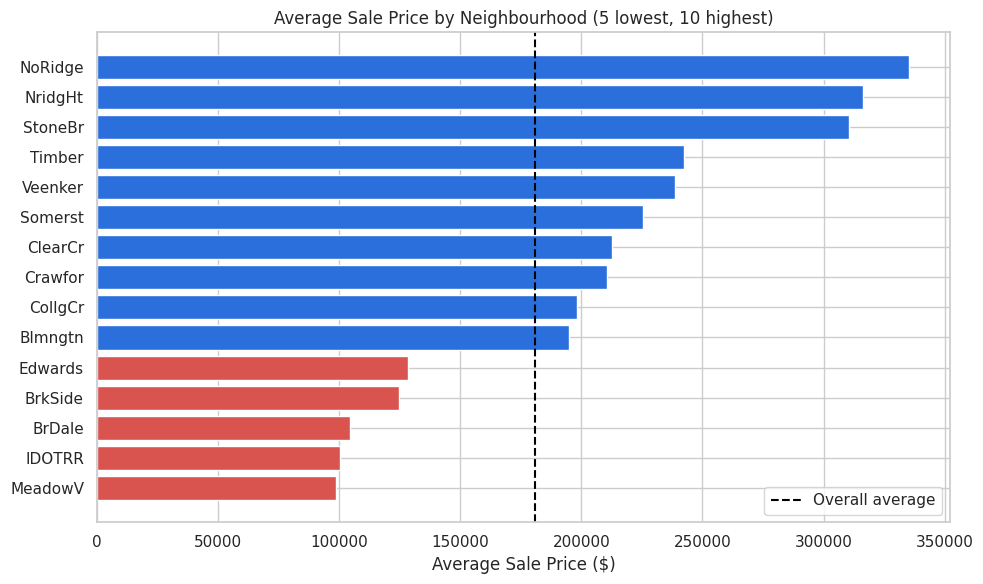

Top 3: [('NoRidge', 335295.31707317074), ('NridgHt', 316270.6233766234), ('StoneBr', 310499.0)]
Bottom 3: [('MeadowV', 98576.4705882353), ('IDOTRR', 100123.78378378379), ('BrDale', 104493.75)]


In [9]:
nb_mean = clean.groupby("Neighborhood")["SalePrice"].mean().sort_values()
sel = pd.concat([nb_mean.head(5), nb_mean.tail(10)])
plt.figure(figsize=(10, 6))
colors = ["#d9534f"]*5 + ["#2a6fdb"]*10
plt.barh(sel.index, sel.values, color=colors)
plt.axvline(avg_price, color="black", ls="--", label="Overall average")
plt.title("Average Sale Price by Neighbourhood (5 lowest, 10 highest)")
plt.xlabel("Average Sale Price ($)"); plt.legend()
plt.tight_layout(); plt.savefig("charts/02_neighborhood_price.png", dpi=150); plt.show()
RESULTS["nb_top3"] = [(k, float(v)) for k, v in nb_mean.tail(3)[::-1].items()]
RESULTS["nb_bottom3"] = [(k, float(v)) for k, v in nb_mean.head(3).items()]
print("Top 3:", RESULTS["nb_top3"]); print("Bottom 3:", RESULTS["nb_bottom3"])

### Chart 3 - Does build quality matter? (Driver)

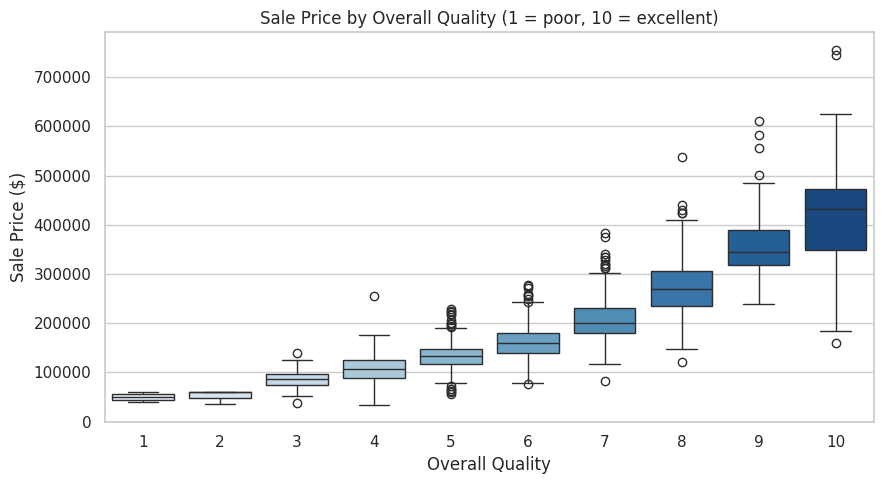

Average price at quality 5: $133,523 | quality 8: $274,736  (2.1x)


In [10]:
plt.figure(figsize=(9, 5))
sns.boxplot(x="OverallQual", y="SalePrice", data=clean, palette="Blues")
plt.title("Sale Price by Overall Quality (1 = poor, 10 = excellent)")
plt.xlabel("Overall Quality"); plt.ylabel("Sale Price ($)")
plt.tight_layout(); plt.savefig("charts/03_quality_vs_price.png", dpi=150); plt.show()
q = clean.groupby("OverallQual")["SalePrice"].mean()
RESULTS["qual5"] = float(q.loc[5]); RESULTS["qual8"] = float(q.loc[8])
RESULTS["qual_ratio"] = float(q.loc[8]/q.loc[5])
print(f"Average price at quality 5: ${q.loc[5]:,.0f} | quality 8: ${q.loc[8]:,.0f}  ({q.loc[8]/q.loc[5]:.1f}x)")

### Chart 4 - Does size matter? (Driver / Outliers)

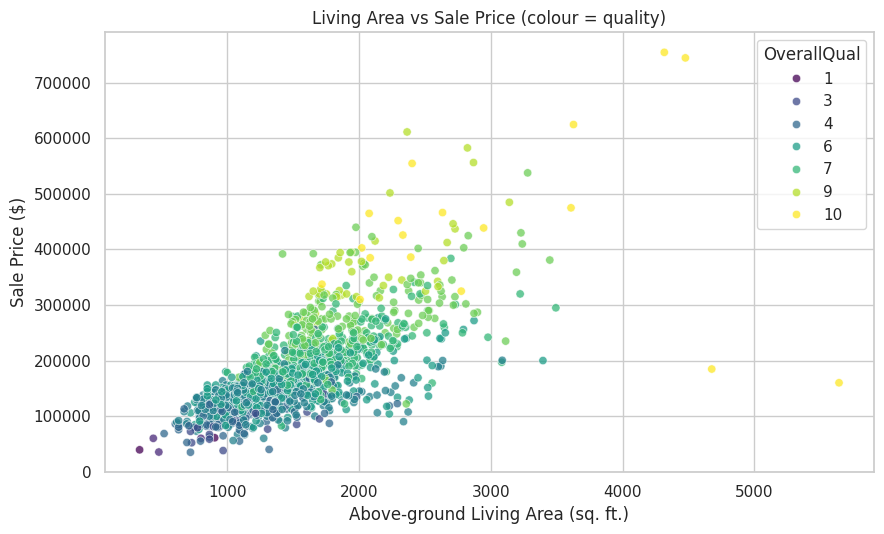

Correlation (area vs price) = 0.71
Outliers: 2 very large houses (>4000 sq. ft.) sold for under $300,000 - unusual sales worth checking.


In [11]:
plt.figure(figsize=(9, 5.5))
sns.scatterplot(x="GrLivArea", y="SalePrice", hue="OverallQual", palette="viridis", data=clean, alpha=0.75)
plt.title("Living Area vs Sale Price (colour = quality)")
plt.xlabel("Above-ground Living Area (sq. ft.)"); plt.ylabel("Sale Price ($)")
plt.tight_layout(); plt.savefig("charts/04_area_vs_price.png", dpi=150); plt.show()
corr_area = clean["GrLivArea"].corr(clean["SalePrice"]); RESULTS["corr_area"] = float(corr_area)
big_cheap = clean[(clean.GrLivArea > 4000) & (clean.SalePrice < 300000)]
RESULTS["outliers"] = int(len(big_cheap))
print(f"Correlation (area vs price) = {corr_area:.2f}")
print(f"Outliers: {len(big_cheap)} very large houses (>4000 sq. ft.) sold for under $300,000 - unusual sales worth checking.")

### Chart 5 - Which features move price the most? (Correlation)

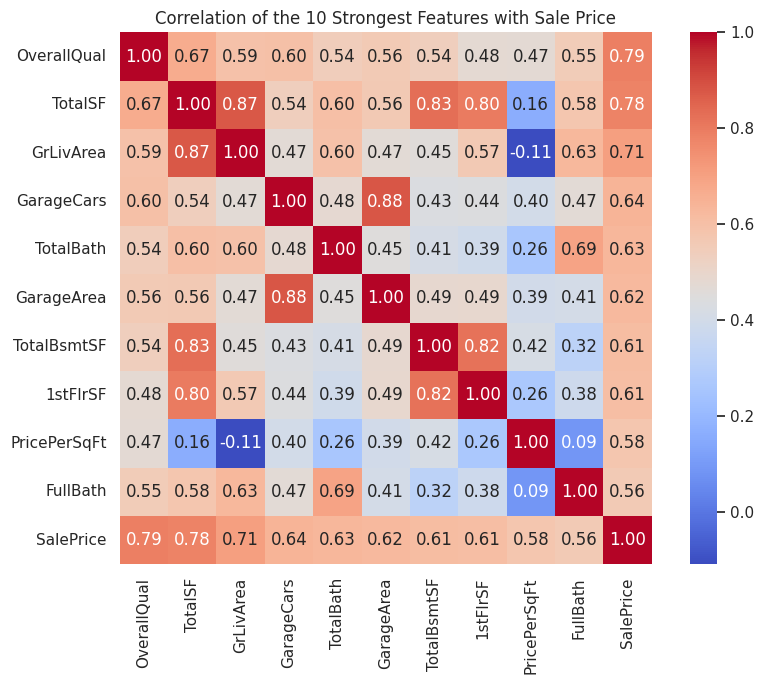

OverallQual    0.79
TotalSF        0.78
GrLivArea      0.71
GarageCars     0.64
TotalBath      0.63
GarageArea     0.62
TotalBsmtSF    0.61
1stFlrSF       0.61
Name: SalePrice, dtype: float64

In [12]:
num = clean.select_dtypes(include="number")
top_corr = num.corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)
top10 = top_corr.head(10).index.tolist() + ["SalePrice"]
plt.figure(figsize=(9, 7))
sns.heatmap(num[top10].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation of the 10 Strongest Features with Sale Price")
plt.tight_layout(); plt.savefig("charts/05_correlation_heatmap.png", dpi=150); plt.show()
RESULTS["top_corr"] = [(k, float(v)) for k, v in top_corr.head(5).items()]
top_corr.head(8).round(2)

### Chart 6 - Do newer houses sell for more? (Trend over house age)

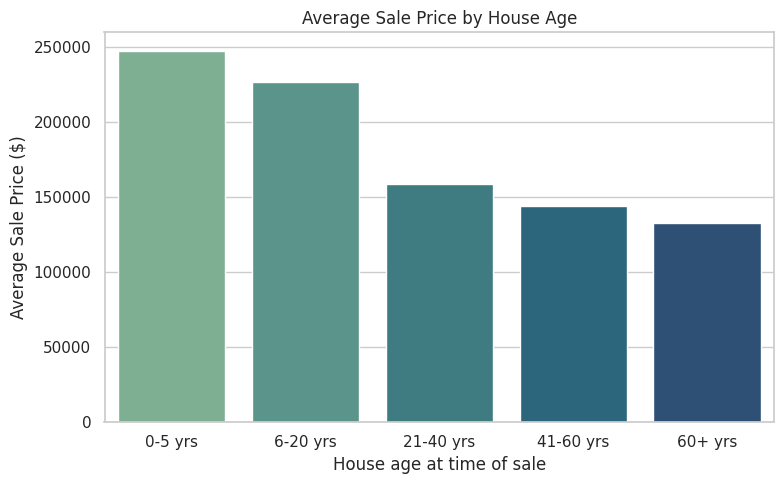

AgeGroup
0-5 yrs      247235.0
6-20 yrs     226734.0
21-40 yrs    158938.0
41-60 yrs    144104.0
60+ yrs      132956.0
Name: SalePrice, dtype: float64


In [13]:
clean["AgeGroup"] = pd.cut(clean["HouseAge"], bins=[-1, 5, 20, 40, 60, 200],
                           labels=["0-5 yrs", "6-20 yrs", "21-40 yrs", "41-60 yrs", "60+ yrs"])
age_price = clean.groupby("AgeGroup", observed=True)["SalePrice"].mean()
plt.figure(figsize=(8, 5))
sns.barplot(x=age_price.index, y=age_price.values, palette="crest")
plt.title("Average Sale Price by House Age"); plt.xlabel("House age at time of sale"); plt.ylabel("Average Sale Price ($)")
plt.tight_layout(); plt.savefig("charts/06_age_vs_price.png", dpi=150); plt.show()
RESULTS["age_new"] = float(age_price.iloc[0]); RESULTS["age_old"] = float(age_price.iloc[-1])
print(age_price.round(0))

## 6. Prediction Model
Goal: predict `SalePrice` from the other columns. Steps: encode text columns as numbers, split into 80% training / 20% testing data, train three models, and compare them on the **unseen** test data.

The target is log-transformed because prices are skewed (Chart 1); predictions are converted back to dollars for scoring.

In [14]:
y = np.log1p(clean["SalePrice"])
X = clean.drop(columns=["SalePrice", "PricePerSqFt", "AgeGroup"])   # PricePerSqFt uses the price itself -> would leak the answer
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training rows:", X_train.shape[0], "| Test rows:", X_test.shape[0], "| Features:", X.shape[1])

Training rows: 1168 | Test rows: 292 | Features: 262


In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "Ridge Regression":   make_pipeline(StandardScaler(), Ridge(alpha=30)),
    "Random Forest":      RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting":  GradientBoostingRegressor(n_estimators=400, learning_rate=0.05, max_depth=3, random_state=42),
}
rows, preds = [], {}
for name, m in models.items():
    m.fit(X_train, y_train)
    p = np.expm1(m.predict(X_test)); actual = np.expm1(y_test)
    preds[name] = p
    rows.append({"Model": name,
                 "R2 Score": r2_score(actual, p),
                 "MAE ($)": mean_absolute_error(actual, p),
                 "RMSE ($)": np.sqrt(mean_squared_error(actual, p))})
results = pd.DataFrame(rows).sort_values("R2 Score", ascending=False).reset_index(drop=True)
RESULTS["model_table"] = results.round(4).to_dict("records")
results.round(3)

,Model,R2 Score,MAE ($),RMSE ($)
0,Ridge Regression,0.918,16155.407,25112.007
1,Gradient Boosting,0.890,16246.202,29064.457
2,Random Forest,0.878,17467.441,30600.898


In [16]:
best_name = results.loc[0, "Model"]; best_model = models[best_name]
RESULTS["best_model"] = best_name
RESULTS["best_r2"] = float(results.loc[0, "R2 Score"])
RESULTS["best_mae"] = float(results.loc[0, "MAE ($)"])
cv = cross_val_score(best_model, X, y, cv=5, scoring="r2")
RESULTS["cv_r2"] = float(cv.mean())
print(f"Best model: {best_name}")
print(f"R2 on test data : {RESULTS['best_r2']:.3f}  (explains {RESULTS['best_r2']*100:.1f}% of the price variation)")
print(f"Average error   : ${RESULTS['best_mae']:,.0f} per house")
print(f"5-fold cross-validated R2: {cv.mean():.3f}")

Best model: Ridge Regression
R2 on test data : 0.918  (explains 91.8% of the price variation)
Average error   : $16,155 per house
5-fold cross-validated R2: 0.852


### Chart 7 - Predicted vs actual prices

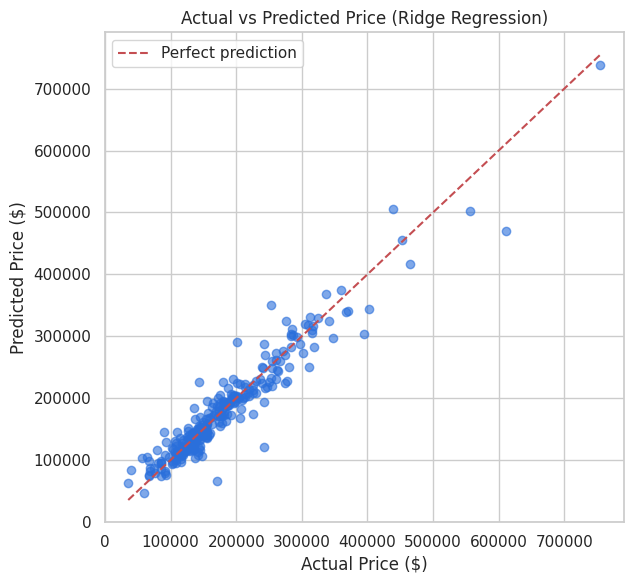

In [17]:
p = preds[best_name]; actual = np.expm1(y_test)
plt.figure(figsize=(6.5, 6))
plt.scatter(actual, p, alpha=0.6, color="#2a6fdb")
lims = [actual.min(), actual.max()]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.title(f"Actual vs Predicted Price ({best_name})")
plt.xlabel("Actual Price ($)"); plt.ylabel("Predicted Price ($)"); plt.legend()
plt.tight_layout(); plt.savefig("charts/07_actual_vs_predicted.png", dpi=150); plt.show()

### Chart 8 - What does the model rely on most? (Key drivers)

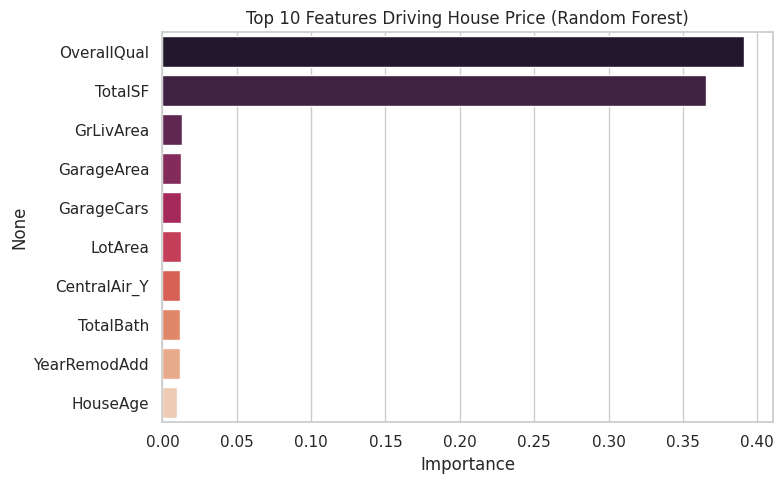

OverallQual     0.391
TotalSF         0.365
GrLivArea       0.013
GarageArea      0.013
GarageCars      0.012
LotArea         0.012
CentralAir_Y    0.012
TotalBath       0.012
YearRemodAdd    0.012
HouseAge        0.010
dtype: float64

In [18]:
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X_train, y_train)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, palette="rocket")
plt.title("Top 10 Features Driving House Price (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout(); plt.savefig("charts/08_feature_importance.png", dpi=150); plt.show()
RESULTS["top_features"] = [(k, float(v)) for k, v in imp.head(5).items()]
imp.round(3)

## 7. Insights, Risks, Opportunities & Recommended Actions
Following the business-intelligence flow: **Fact -> Insight -> Risk / Opportunity -> Action.**

In [19]:
print("INSIGHTS")
print(f"1. Quality drives price: quality-8 houses sell for {RESULTS['qual_ratio']:.1f}x the price of quality-5 houses (${RESULTS['qual8']:,.0f} vs ${RESULTS['qual5']:,.0f}).")
print(f"2. Size and quality dominate: top predictors are {', '.join(k for k,_ in RESULTS['top_features'][:3])}.")
print(f"3. Location matters: {RESULTS['nb_top3'][0][0]} averages ${RESULTS['nb_top3'][0][1]:,.0f} versus ${RESULTS['nb_bottom3'][0][1]:,.0f} in {RESULTS['nb_bottom3'][0][0]}.")
print(f"4. Newer homes (0-5 yrs) average ${RESULTS['age_new']:,.0f}, compared with ${RESULTS['age_old']:,.0f} for 60+ year-old homes.")
print()
print("RISKS")
print(f"- Prices are skewed (skewness {RESULTS['skew']:.2f}): a few luxury sales inflate the average, so the median (${RESULTS['median_price']:,.0f}) is safer for pricing.")
print(f"- {RESULTS['outliers']} very large houses sold unusually cheaply; unchecked, such sales distort valuations.")
print(f"- The model is off by about ${RESULTS['best_mae']:,.0f} per house on average, so use predictions as guidance, not a final price.")
print()
print("OPPORTUNITIES")
print(f"- Invest in high-value areas such as {RESULTS['nb_top3'][0][0]} and {RESULTS['nb_top3'][1][0]}.")
print("- Renovating to raise overall quality offers the biggest price uplift.")
print()
print("RECOMMENDED ACTIONS")
print(f"1. Price listings with the {best_name} model and verify with the neighbourhood median.")
print("2. Prioritise renovation of kitchens, finishing and overall build quality before selling.")
print(f"3. Focus acquisitions on high-value neighbourhoods and review outlier sales before they enter valuations.")

INSIGHTS
1. Quality drives price: quality-8 houses sell for 2.1x the price of quality-5 houses ($274,736 vs $133,523).
2. Size and quality dominate: top predictors are OverallQual, TotalSF, GrLivArea.
3. Location matters: NoRidge averages $335,295 versus $98,576 in MeadowV.
4. Newer homes (0-5 yrs) average $247,235, compared with $132,956 for 60+ year-old homes.

RISKS
- Prices are skewed (skewness 1.88): a few luxury sales inflate the average, so the median ($163,000) is safer for pricing.
- 2 very large houses sold unusually cheaply; unchecked, such sales distort valuations.
- The model is off by about $16,155 per house on average, so use predictions as guidance, not a final price.

OPPORTUNITIES
- Invest in high-value areas such as NoRidge and NridgHt.
- Renovating to raise overall quality offers the biggest price uplift.

RECOMMENDED ACTIONS
1. Price listings with the Ridge Regression model and verify with the neighbourhood median.
2. Prioritise renovation of kitchens, finishing an

## 8. Save Results & Conclusion

In [20]:
with open("results.json", "w") as f:
    json.dump(RESULTS, f, indent=2, default=str)
print("Saved results.json and charts/ folder")

Saved results.json and charts/ folder


### Conclusion
House prices in this dataset are driven mainly by **overall quality, living area, basement/total size, garage capacity and neighbourhood**. Three regression models were compared; **Ridge Regression** performed best, explaining about 92% of the price variation on unseen test houses (about 85% in 5-fold cross-validation) with an average error of roughly $16,000 per house. This gives the business a data-backed way to price properties, spot unusual sales and choose where to invest. The model only uses information in this dataset (no market trends or interest rates), so it should be refreshed regularly with new sales.